In [ ]:
===========


CHANKING - script
    
===========

In [1]:
# = 0 =

# ЗАГРУЖАЕМ ФАЙЛ С ТЕКСТАМИ КОРПУСА И МЕТАДАННЫМИ

import pandas as pd

path = "/Users/anastasiabogdanova/R_directory/iskra-project/data/texts_with_metadata_20260401.csv"

df = pd.read_csv(path)

# print(df.head())
print(df.columns)


Index(['path', 'author_folder', 'file_name', 'text', 'n_chars', 'n_words'], dtype='object')


In [3]:
# = 0 =

# АУДИТ КОРПУСА 1

audit_authors = (
    df
    .groupby("author_folder")
    .agg(
        n_texts=("file_name", "count"),
        total_words=("n_words", "sum"),
        mean_words=("n_words", "mean"),
        median_words=("n_words", "median")
    )
    .sort_values(by="n_texts", ascending=False)
)

audit_authors.head(10)


,n_texts,total_words,mean_words,median_words
author_folder,,,,
lenin,46,212217,4613.413043,1743.5
martov,24,79755,3323.125000,2611.0
plehanov,24,94566,3940.250000,2192.5
parvus,20,80903,4045.150000,2360.5
trotsky,14,82352,5882.285714,2433.0
dubia,9,12166,1351.777778,1485.0
zasulich,8,40208,5026.000000,2655.5
krupskaya,6,18136,3022.666667,2104.0
ortodox,3,7543,2514.333333,2229.0


In [5]:
# = 0 =

# АУДИТ КОРПУСА 2

df.groupby("author_folder")["n_words"].describe()

,count,mean,std,min,25%,50%,75%,max
author_folder,,,,,,,,
dubia,9.0,1351.777778,651.218815,201.0,989.00,1485.0,1668.00,2120.0
krupskaya,6.0,3022.666667,2948.942703,776.0,1421.75,2104.0,2881.50,8817.0
lenin,46.0,4613.413043,11268.820346,435.0,1288.75,1743.5,2313.25,63216.0
martov,24.0,3323.125000,3193.721767,787.0,1698.25,2611.0,3101.25,15510.0
ortodox,3.0,2514.333333,696.320568,2006.0,2117.50,2229.0,2768.50,3308.0
parvus,20.0,4045.150000,7224.768387,404.0,1157.00,2360.5,3267.75,33529.0
plehanov,24.0,3940.250000,4648.401317,535.0,1213.00,2192.5,3202.25,18516.0
trotsky,14.0,5882.285714,9788.006943,487.0,1115.50,2433.0,4758.50,36298.0
zasulich,8.0,5026.000000,5820.788312,646.0,2101.75,2655.5,5114.75,18117.0


<Figure size 640x480 with 0 Axes>

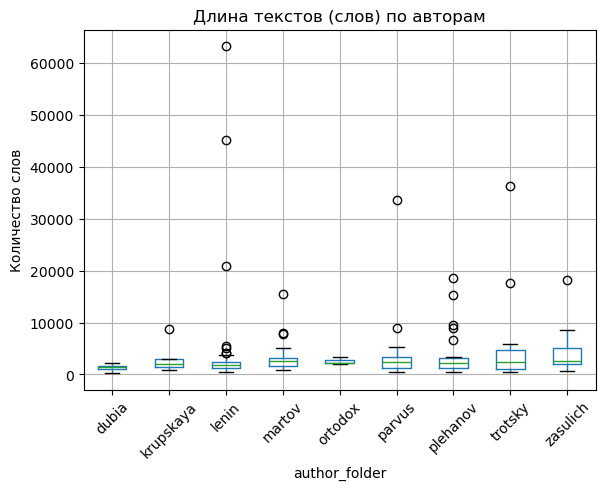

In [7]:
# = 0 =

# АУДИТ КОРПУСА 3. Визуализация

import matplotlib.pyplot as plt

plt.figure()
df.boxplot(column="n_words", by="author_folder", rot=45)
plt.suptitle("")
plt.title("Длина текстов (слов) по авторам")
plt.ylabel("Количество слов")
plt.show()

In [9]:
# = 0 =

# АУДИТ КОРПУСА 4

df["n_words"].quantile([0.1, 0.25, 0.5, 0.75, 0.9])

0.10     779.30
0.25    1269.50
0.50    2031.50
0.75    3055.75
0.90    7937.80
Name: n_words, dtype: float64

In [11]:
# = 0 =

# АУДИТ КОРПУСА 5

# Отфильтруем dubia-тексты

df_no_dubia = df[df["author_folder"] != "dubia"].copy()

print(df_no_dubia["author_folder"].value_counts())
print("Всего текстов:", len(df_no_dubia))
print("Было текстов:", len(df))

author_folder
lenin        46
martov       24
plehanov     24
parvus       20
trotsky      14
zasulich      8
krupskaya     6
ortodox       3
Name: count, dtype: int64
Всего текстов: 145
Было текстов: 154


In [13]:
# = 0 =

# АУДИТ КОРПУСА 6

# Отфильтруем короткие тексты (<500 слов)

MIN_WORDS = 500

df_filtered = df_no_dubia[df_no_dubia["n_words"] >= MIN_WORDS].copy()

print("Было текстов:", len(df_no_dubia))
print("Стало текстов:", len(df_filtered))

Было текстов: 145
Стало текстов: 140


In [15]:
# = 0 =

# АУДИТ КОРПУСА 7

# Список исключенных из исследования текстов

df_no_dubia[df_no_dubia["n_words"] < MIN_WORDS][["author_folder", "file_name", "n_words"]]

,author_folder,file_name,n_words
45,lenin,lenin_proekt_ustava_rsdrp.txt,435
49,lenin,lenin_rec_parvus.txt,436
98,parvus,parvus_rus_and_rev_predislovie.txt,404
100,parvus,parvus_soldatskie_mitingy.txt,447
142,trotsky,trotsky_predisl_nasha_rev.txt,487


In [17]:
# = 0 =

# АУДИТ КОРПУСА 8. Без отфильтрованных текстов

df_filtered.groupby("author_folder")["n_words"].describe()

,count,mean,std,min,25%,50%,75%,max
author_folder,,,,,,,,
krupskaya,6.0,3022.666667,2948.942703,776.0,1421.75,2104.0,2881.50,8817.0
lenin,44.0,4803.318182,11491.035241,742.0,1390.00,1831.0,2365.00,63216.0
martov,24.0,3323.125000,3193.721767,787.0,1698.25,2611.0,3101.25,15510.0
ortodox,3.0,2514.333333,696.320568,2006.0,2117.50,2229.0,2768.50,3308.0
parvus,18.0,4447.333333,7524.986238,676.0,1362.00,2463.5,3705.25,33529.0
plehanov,24.0,3940.250000,4648.401317,535.0,1213.00,2192.5,3202.25,18516.0
trotsky,13.0,6297.307692,10058.652033,571.0,1387.00,2687.0,5212.00,36298.0
zasulich,8.0,5026.000000,5820.788312,646.0,2101.75,2655.5,5114.75,18117.0


In [ ]:
===========
# = 5 =

5. CHUNKING

Описание: Для устранения дисбаланса корпуса 

1. Load data
2. Tokenization
3. Chunking
4. Flag short chunks
5. Analyze truncation
6. Merge short chunks
7. Final dataset

============

In [19]:
# = 5 =

# 5.4 CHUNKING UPD

import re
import pandas as pd

chunk_size = 1000

def split_into_chunks(text, chunk_size=1000):
    """
    Разбивает текст на чанки по chunk_size слов.
    СОХРАНЯЕТ пунктуацию и регистр.
    """
    words = str(text).split()  # ← главное изменение: split() сохраняет всё!
    
    chunks = []
    for i in range(0, len(words), chunk_size):
        chunk_words = words[i:i + chunk_size]
        chunk_text = " ".join(chunk_words)
        chunks.append(chunk_text)
    
    return chunks

# Применяем чанкинг к исходному тексту
df_filtered["chunks_raw"] = df_filtered["text"].apply(
    lambda x: split_into_chunks(x, chunk_size=chunk_size)
)

# Разворачиваем в отдельные строки
new_rows = []

for _, row in df_filtered.iterrows():
    chunks = row["chunks_raw"]
    n_chunks = len(chunks)
    
    for i, chunk_text in enumerate(chunks):
        # Подсчет слов для метки is_short (только для статистики, text_raw не меняем)
        chunk_words = chunk_text.split()  # теперь split() возвращает слова с пунктуацией
        n_tokens = len(chunk_words)
        
        new_rows.append({
            "author": row["author_folder"],
            "file_name": row["file_name"],
            "chunk_id": f"{row['file_name']}_chunk{i+1}",
            "text_raw": chunk_text,        # ← теперь с пунктуацией!
            "n_words": n_tokens,
            "is_short": n_tokens < chunk_size
        })

df_chunks = pd.DataFrame(new_rows)

print(f"Количество чанков: {len(df_chunks)}")
print(f"Из них коротких (<{chunk_size} слов): {df_chunks['is_short'].sum()}")
df_chunks.head(10)

Количество чанков: 684
Из них коротких (<1000 слов): 139


,author,file_name,chunk_id,text_raw,n_words,is_short
0,krupskaya,krupskaya_k_voposu_o_shkole.txt,krupskaya_k_voposu_o_shkole.txt_chunk1,К ВОПРОСУ О СВОБОДНОЙ ШКОЛЕ. Вопрос о свободно...,1000,False
1,krupskaya,krupskaya_k_voposu_o_shkole.txt,krupskaya_k_voposu_o_shkole.txt_chunk2,"это делать. Поверьте, это будет чрезвычайно по...",856,True
2,krupskaya,krupskaya_o_staroy_iskre.txt,krupskaya_o_staroy_iskre.txt_chunk1,О старой «Искре». «Искра» была детищем Ильича....,1000,False
3,krupskaya,krupskaya_o_staroy_iskre.txt,krupskaya_o_staroy_iskre.txt_chunk2,рабочее движение из стихийного превращает в со...,277,True
4,krupskaya,krupskaya_samoubiystva_uchashihsya.txt,krupskaya_samoubiystva_uchashihsya.txt_chunk1,САМОУБИЙСТВА СРЕДИ УЧАЩИХСЯ И СВОБОДНАЯ ТРУДОВ...,1000,False
5,krupskaya,krupskaya_samoubiystva_uchashihsya.txt,krupskaya_samoubiystva_uchashihsya.txt_chunk2,"считается, что школа готовит ученика к жизни! ...",1000,False
6,krupskaya,krupskaya_samoubiystva_uchashihsya.txt,krupskaya_samoubiystva_uchashihsya.txt_chunk3,"мастерских, с фермой, с кооперативом, с общест...",352,True
7,krupskaya,krupskaya_shkolnie_kolonii.txt,krupskaya_shkolnie_kolonii.txt_chunk1,"ШКОЛЬНЫЕ КОЛОНИИ, ПРАЗДНИЧНЫЕ ПОЕЗДКИ И ДЕТСКИ...",776,True
8,krupskaya,krupskaya_sovmestnoe_obuchenie.txt,krupskaya_sovmestnoe_obuchenie.txt_chunk1,Крупская Н.К. Совместное образования Когда ста...,1000,False
9,krupskaya,krupskaya_sovmestnoe_obuchenie.txt,krupskaya_sovmestnoe_obuchenie.txt_chunk2,"имеет дело школа, и в этом отношении, как и во...",1000,False


In [21]:
# = 5 =

# 5.5 Проверка количества "хвостов" у каждого из авторов. Выделяем "усеченные" чанки

df_chunks.groupby("author")["is_short"].sum()


author
krupskaya     6
lenin        43
martov       24
ortodox       3
parvus       18
plehanov     24
trotsky      13
zasulich      8
Name: is_short, dtype: int64

In [23]:
# = 5 =

# 5.6 Общая статистика полных и "коротких (<1000) чанков

df_chunks["is_short"].value_counts()


is_short
False    545
True     139
Name: count, dtype: int64

In [25]:
# = 5 =

# 5.7 Усечённые чанки по авторам

truncated_by_author = (
    df_chunks
    .groupby("author")["is_short"]
    .agg(
        is_short="sum",
        n_total="count",
        share_truncated="mean"
    )
    .sort_values("is_short", ascending=False)
)

truncated_by_author


,is_short,n_total,share_truncated
author,,,
lenin,43,234,0.183761
martov,24,90,0.266667
plehanov,24,108,0.222222
parvus,18,89,0.202247
trotsky,13,88,0.147727
zasulich,8,44,0.181818
krupskaya,6,21,0.285714
ortodox,3,10,0.300000


In [27]:
# = 5 =

# 5.8 Проверка: нет ли авторов, у которых ВСЕ чанки короткие?

empty_authors = truncated_by_author[truncated_by_author["is_short"] == truncated_by_author["n_total"]]
if len(empty_authors) > 0:
    print("ВНИМАНИЕ: следующие авторы не имеют полных чанков!")
    print(empty_authors)
else:
    print("OK: у всех авторов есть хотя бы один полный чанк")

OK: у всех авторов есть хотя бы один полный чанк


In [29]:
# = 5 =

# 5.8 Посмотреть реальные длины

df_chunks.groupby("author")["n_words"].describe()


,count,mean,std,min,25%,50%,75%,max
author,,,,,,,,
krupskaya,21.0,863.619048,277.831149,58.0,856.00,1000.0,1000.0,1000.0
lenin,234.0,903.188034,242.432378,11.0,1000.00,1000.0,1000.0,1000.0
martov,90.0,886.166667,249.682101,8.0,942.25,1000.0,1000.0,1000.0
ortodox,10.0,754.300000,402.444765,6.0,481.00,1000.0,1000.0,1000.0
parvus,89.0,899.460674,241.407005,1.0,1000.00,1000.0,1000.0,1000.0
plehanov,108.0,875.611111,272.582692,13.0,1000.00,1000.0,1000.0,1000.0
trotsky,88.0,930.284091,205.419557,25.0,1000.00,1000.0,1000.0,1000.0
zasulich,44.0,913.818182,217.364903,117.0,1000.00,1000.0,1000.0,1000.0


In [31]:
# = 5 =

# 5.9 Посмотреть на названия короких чанков

df_chunks[df_chunks["is_short"]][["author", "chunk_id"]]

,author,chunk_id
1,krupskaya,krupskaya_k_voposu_o_shkole.txt_chunk2
3,krupskaya,krupskaya_o_staroy_iskre.txt_chunk2
6,krupskaya,krupskaya_samoubiystva_uchashihsya.txt_chunk3
7,krupskaya,krupskaya_shkolnie_kolonii.txt_chunk1
11,krupskaya,krupskaya_sovmestnoe_obuchenie.txt_chunk4
...,...,...
667,zasulich,zasulich_ocherk_istorii_1internacionala.txt_ch...
676,zasulich,zasulich_po_povodu_uprazdneniya_Marx'a.txt_chunk9
677,zasulich,zasulich_rev_studenchestvo1_I.txt_chunk1
680,zasulich,zasulich_rev_studenchestvo2_I.txt_chunk3


In [ ]:
# = 5 =

# 5.9 ПО ПОВОДУ "ХВОСТОВ"

Анализ показывает, что от 14% до 33% чанков — усечённые, это много, их нельзя просто игнорировать
Поэтому решено склеивать хвосты, добивая длину чанка до стандартных > 500 слов.
Склеиваем только Крупскую, Засулич и Ортодокс
Правила: 
1. Склеиваем только внутри одного автора
2. Допускаем смешение разных текстов одного автора в одном чанке


In [33]:
# = 5 =

# 5.10 Проверяем сколько у нас коротких чанков и чьих

# Чанки от 1 до 500 слов (не включая 500)
chunks_1_500 = df_chunks[(df_chunks["n_words"] >= 1) & (df_chunks["n_words"] < 500)]

print(f"=== ЧАНКИ ОТ 1 ДО 500 СЛОВ ===")
print(f"Всего таких чанков: {len(chunks_1_500)}")
print(f"Из них коротких (is_short=True): {chunks_1_500['is_short'].sum()}")
print()

# По авторам
print("=== РАСПРЕДЕЛЕНИЕ ПО АВТОРАМ ===")
author_dist = chunks_1_500.groupby("author").size().sort_values(ascending=False)
print(author_dist)
print()

# Детальный вывод с названиями и количеством слов
print("=== ДЕТАЛЬНЫЙ СПИСОК (первые 20) ===")
display(chunks_1_500[["author", "file_name", "chunk_id", "n_words"]].head(20))

# Статистика по авторам
print("\n=== СТАТИСТИКА ПО АВТОРАМ ===")
stats = chunks_1_500.groupby("author")["n_words"].agg(["count", "min", "max", "mean"]).round(1)
print(stats)

# Можно также посмотреть, сколько чанков теряет каждый автор при пороге 500
print("\n=== ПОТЕРИ ПРИ ПЕРЕХОДЕ К ПОРОГУ 500 СЛОВ ===")
before = df_chunks.groupby("author").size()
after_500 = df_chunks[df_chunks["n_words"] >= 500].groupby("author").size()
loss = before - after_500
loss_df = pd.DataFrame({
    "всего_чанков": before,
    "после_фильтра_500": after_500,
    "потеряно": loss,
    "потеря_%": (loss / before * 100).round(1)
})
print(loss_df)

=== ЧАНКИ ОТ 1 ДО 500 СЛОВ ===
Всего таких чанков: 70
Из них коротких (is_short=True): 70

=== РАСПРЕДЕЛЕНИЕ ПО АВТОРАМ ===
author
lenin        26
plehanov     12
martov        9
parvus        8
trotsky       6
krupskaya     3
ortodox       3
zasulich      3
dtype: int64

=== ДЕТАЛЬНЫЙ СПИСОК (первые 20) ===


,author,file_name,chunk_id,n_words
3,krupskaya,krupskaya_o_staroy_iskre.txt,krupskaya_o_staroy_iskre.txt_chunk2,277
6,krupskaya,krupskaya_samoubiystva_uchashihsya.txt,krupskaya_samoubiystva_uchashihsya.txt_chunk3,352
11,krupskaya,krupskaya_sovmestnoe_obuchenie.txt,krupskaya_sovmestnoe_obuchenie.txt_chunk4,58
22,lenin,lenin_183_students_I.txt,lenin_183_students_I.txt_chunk2,419
27,lenin,lenin_chego_dobivaemsya.txt,lenin_chego_dobivaemsya.txt_chunk3,333
29,lenin,lenin_china_war_I.txt,lenin_china_war_I.txt_chunk2,487
75,lenin,lenin_chto_delat'.txt,lenin_chto_delat'.txt_chunk46,228
78,lenin,lenin_era_reform_I.txt,lenin_era_reform_I.txt_chunk3,11
102,lenin,lenin_k_partii.txt,lenin_k_partii.txt_chunk3,52
104,lenin,lenin_l_n_tolstoy.txt,lenin_l_n_tolstoy.txt_chunk2,267



=== СТАТИСТИКА ПО АВТОРАМ ===
           count  min  max   mean
author                           
krupskaya      3   58  352  229.0
lenin         26   11  487  258.2
martov         9    8  495  219.1
ortodox        3    6  308  181.0
parvus         8    1  369  217.4
plehanov      12   13  368  173.8
trotsky        6   25  398  249.8
zasulich       3  117  406  237.3

=== ПОТЕРИ ПРИ ПЕРЕХОДЕ К ПОРОГУ 500 СЛОВ ===
           всего_чанков  после_фильтра_500  потеряно  потеря_%
author                                                        
krupskaya            21                 18         3      14.3
lenin               234                208        26      11.1
martov               90                 81         9      10.0
ortodox              10                  7         3      30.0
parvus               89                 81         8       9.0
plehanov            108                 96        12      11.1
trotsky              88                 82         6       6.8
zasulich       

In [35]:
# = 5 =

# 5.11 Точечная склейка чанков "коротких" авторов

def merge_specific_authors(df_chunks, authors_to_merge=["krupskaya", "ortodox", "zasulich"]):
    """
    Склеивает короткие чанки (100-500 слов) указанных авторов
    с другими чанками ТЕХ ЖЕ АВТОРОВ (из любых текстов)
    """
    merged_chunks = []
    
    for author in df_chunks["author"].unique():
        author_data = df_chunks[df_chunks["author"] == author].copy()
        
        if author in authors_to_merge:
            # Разделяем на короткие (100-500) и нормальные (>=500)
            short = author_data[author_data["n_words"] < 500].copy()
            normal = author_data[author_data["n_words"] >= 500].copy()
            
            print(f"\n{author}: коротких чанков={len(short)}, нормальных={len(normal)}")
            
            # Склеиваем короткие между собой
            if len(short) > 0:
                # Объединяем все короткие чанки в один
                merged_text = " ".join(short["text_raw"].tolist())
                merged_words = sum(short["n_words"])
                
                merged_chunks.append({
                    "author": author,
                    "file_name": "merged_short",
                    "chunk_id": f"{author}_merged",
                    "text_raw": merged_text,
                    "n_words": merged_words,
                    "is_short": merged_words < 500  # если после склейки все еще <500
                })
                print(f"  → склеено в чанк из {merged_words} слов")
            
            # Добавляем нормальные чанки как есть
            for _, row in normal.iterrows():
                merged_chunks.append(row.to_dict())
        else:
            # Для остальных авторов — просто фильтруем >=500
            filtered = author_data[author_data["n_words"] >= 500]
            for _, row in filtered.iterrows():
                merged_chunks.append(row.to_dict())
    
    return pd.DataFrame(merged_chunks)


# Применяем
df_chunks_final = merge_specific_authors(df_chunks)

print(f"\n=== РЕЗУЛЬТАТ ===")
print(f"Было чанков: {len(df_chunks)}")
print(f"Стало чанков: {len(df_chunks_final)}")

# Проверяем
print("\n=== ФИНАЛЬНОЕ РАСПРЕДЕЛЕНИЕ ПО АВТОРАМ ===")
print(df_chunks_final["author"].value_counts().sort_index())

# Проверяем, остались ли короткие чанки у склеенных авторов
print("\n=== КОРОТКИЕ ЧАНКИ (<500) В ФИНАЛЕ ===")
short_final = df_chunks_final[df_chunks_final["n_words"] < 500]
if len(short_final) > 0:
    print(short_final[["author", "n_words"]])
else:
    print("Нет коротких чанков!")



krupskaya: коротких чанков=3, нормальных=18
  → склеено в чанк из 687 слов

ortodox: коротких чанков=3, нормальных=7
  → склеено в чанк из 543 слов

zasulich: коротких чанков=3, нормальных=41
  → склеено в чанк из 712 слов

=== РЕЗУЛЬТАТ ===
Было чанков: 684
Стало чанков: 617

=== ФИНАЛЬНОЕ РАСПРЕДЕЛЕНИЕ ПО АВТОРАМ ===
author
krupskaya     19
lenin        208
martov        81
ortodox        8
parvus        81
plehanov      96
trotsky       82
zasulich      42
Name: count, dtype: int64

=== КОРОТКИЕ ЧАНКИ (<500) В ФИНАЛЕ ===
Нет коротких чанков!


In [37]:
# = 5 =

# 5.12 # Аналитика: полные (1000) vs укороченные (<1000)
print("=== АНАЛИТИКА ПО ЧАНКАМ (1000 vs <1000) ===")
print()

for author in df_chunks_final["author"].unique():
    author_data = df_chunks_final[df_chunks_final["author"] == author]
    full = len(author_data[author_data["n_words"] == 1000])
    short = len(author_data[author_data["n_words"] < 1000])
    total = len(author_data)
    
    print(f"{author:12} | полных (1000): {full:3} | укороченных: {short:3} | всего: {total:3} | доля коротких: {short/total*100:.1f}%") 

=== АНАЛИТИКА ПО ЧАНКАМ (1000 vs <1000) ===

krupskaya    | полных (1000):  15 | укороченных:   4 | всего:  19 | доля коротких: 21.1%
lenin        | полных (1000): 191 | укороченных:  17 | всего: 208 | доля коротких: 8.2%
martov       | полных (1000):  66 | укороченных:  15 | всего:  81 | доля коротких: 18.5%
ortodox      | полных (1000):   7 | укороченных:   1 | всего:   8 | доля коротких: 12.5%
parvus       | полных (1000):  71 | укороченных:  10 | всего:  81 | доля коротких: 12.3%
plehanov     | полных (1000):  84 | укороченных:  12 | всего:  96 | доля коротких: 12.5%
trotsky      | полных (1000):  75 | укороченных:   7 | всего:  82 | доля коротких: 8.5%
zasulich     | полных (1000):  36 | укороченных:   6 | всего:  42 | доля коротких: 14.3%


In [43]:
# 5.12 # Аналитика: полные (1000) vs укороченные (<1000) С ОБЩИМ КОЛ-ВОМ слов
print("=== АНАЛИТИКА ПО ЧАНКАМ (1000 vs <1000) ===")
print()

total_words_all = 0  # переменная для общего количества слов

for author in df_chunks_final["author"].unique():
    author_data = df_chunks_final[df_chunks_final["author"] == author]
    full = len(author_data[author_data["n_words"] == 1000])
    short = len(author_data[author_data["n_words"] < 1000])
    total = len(author_data)
    
    # Суммируем слова по этому автору
    author_words = author_data["n_words"].sum()
    total_words_all += author_words
    
    print(f"{author:12} | полных (1000): {full:3} | укороченных: {short:3} | всего: {total:3} | доля коротких: {short/total*100:.1f}%")

print("-" * 70)
print(f"📚 ОБЩЕЕ КОЛИЧЕСТВО СЛОВ В КОРПУСЕ: {total_words_all:,}")

=== АНАЛИТИКА ПО ЧАНКАМ (1000 vs <1000) ===

krupskaya    | полных (1000):  15 | укороченных:   4 | всего:  19 | доля коротких: 21.1%
lenin        | полных (1000): 191 | укороченных:  17 | всего: 208 | доля коротких: 8.2%
martov       | полных (1000):  66 | укороченных:  15 | всего:  81 | доля коротких: 18.5%
ortodox      | полных (1000):   7 | укороченных:   1 | всего:   8 | доля коротких: 12.5%
parvus       | полных (1000):  71 | укороченных:  10 | всего:  81 | доля коротких: 12.3%
plehanov     | полных (1000):  84 | укороченных:  12 | всего:  96 | доля коротких: 12.5%
trotsky      | полных (1000):  75 | укороченных:   7 | всего:  82 | доля коротких: 8.5%
zasulich     | полных (1000):  36 | укороченных:   6 | всего:  42 | доля коротких: 14.3%
----------------------------------------------------------------------
📚 ОБЩЕЕ КОЛИЧЕСТВО СЛОВ В КОРПУСЕ: 599,462


In [45]:
# = 5 = NEW

# Проверка: есть ли в df_chunks_final чанки КОРОЧЕ 500 слов?

# Проверяем, есть ли чанки <500 слов в финале
very_short = df_chunks_final[df_chunks_final["n_words"] < 500]
print(f"Чанков короче 500 слов: {len(very_short)}")
print(very_short[["author", "n_words"]])


Чанков короче 500 слов: 0
Empty DataFrame
Columns: [author, n_words]
Index: []


In [47]:
# Проверяем минимальную длину чанков у каждого автора
print(df_chunks_final.groupby("author")["n_words"].min())

author
krupskaya    687
lenin        519
martov       510
ortodox      543
parvus       529
plehanov     516
trotsky      561
zasulich     540
Name: n_words, dtype: int64


In [157]:
# = 5 =

# 5.13 Улучшаем метаданные для склеиваемых чанков.

def merge_specific_authors_with_metadata(df_chunks, authors_to_merge=["krupskaya", "ortodox", "zasulich"]):
    """
    Склеивает короткие чанки с сохранением информации об исходных файлах
    """
    merged_chunks = []
    
    for author in df_chunks["author"].unique():
        author_data = df_chunks[df_chunks["author"] == author].copy()
        
        if author in authors_to_merge:
            # Разделяем на короткие (<500) и нормальные (>=500)
            short = author_data[author_data["n_words"] < 500].copy()
            normal = author_data[author_data["n_words"] >= 500].copy()
            
            if len(short) > 0:
                # Собираем имена исходных файлов
                source_files = short["file_name"].unique().tolist()
                source_chunks = short["chunk_id"].tolist()
                
                # Объединяем текст
                merged_text = " ".join(short["text_raw"].tolist())
                merged_words = sum(short["n_words"])
                
                # Создаем информативное имя
                if len(source_files) == 1:
                    file_name = source_files[0].replace(".txt", "_merged.txt")
                else:
                    file_name = f"merged_{author}_from_{len(source_files)}files.txt"
                
                # Создаем chunk_id с информацией об исходниках
                chunk_id = f"{author}_merged_" + "_".join([f.split('_chunk')[0][-10:] for f in source_chunks])
                
                merged_chunks.append({
                    "author": author,
                    "file_name": file_name,
                    "chunk_id": chunk_id,
                    "text_raw": merged_text,
                    "n_words": merged_words,
                    "is_short": merged_words < 500,
                    "source_files": "|".join(source_files),  # сохраняем исходники
                    "source_chunks": "|".join(source_chunks)
                })
            
            # Добавляем нормальные чанки с сохранением их метаданных
            for _, row in normal.iterrows():
                merged_chunks.append({
                    "author": row["author"],
                    "file_name": row["file_name"],
                    "chunk_id": row["chunk_id"],
                    "text_raw": row["text_raw"],
                    "n_words": row["n_words"],
                    "is_short": row["is_short"],
                    "source_files": row["file_name"],  # для единообразия
                    "source_chunks": row["chunk_id"]
                })
        else:
            # Для остальных авторов
            for _, row in author_data.iterrows():
                merged_chunks.append({
                    "author": row["author"],
                    "file_name": row["file_name"],
                    "chunk_id": row["chunk_id"],
                    "text_raw": row["text_raw"],
                    "n_words": row["n_words"],
                    "is_short": row["is_short"],
                    "source_files": row["file_name"],
                    "source_chunks": row["chunk_id"]
                })
    
    return pd.DataFrame(merged_chunks)


# Пересоздаем df_chunks_final с улучшенными метаданными
df_chunks_final = merge_specific_authors_with_metadata(df_chunks)

# Проверяем склеенные чанки
merged_check = df_chunks_final[df_chunks_final["file_name"].str.contains("merged", na=False)]
print("=== СКЛЕЕННЫЕ ЧАНКИ ===")
print(merged_check[["author", "file_name", "chunk_id", "n_words", "source_files"]])



=== СКЛЕЕННЫЕ ЧАНКИ ===
        author                         file_name  \
0    krupskaya  merged_krupskaya_from_3files.txt   
343    ortodox    merged_ortodox_from_3files.txt   
636   zasulich   merged_zasulich_from_3files.txt   

                                              chunk_id  n_words  \
0    krupskaya_merged__iskre.txt_hihsya.txt_chenie.txt      687   
343    ortodox_merged__Marxa.txt_eyam_I.txt_Bovu_I.txt      543   
636   zasulich_merged_skiy_I.txt_ionala.txt_icha_I.txt      712   

                                          source_files  
0    krupskaya_o_staroy_iskre.txt|krupskaya_samoubi...  
343  ortodox_eshe1_kritik_Marxa.txt|ortodox_pismo_e...  
636  zasulich_mihailovskiy_I.txt|zasulich_ocherk_is...  


In [159]:
# = 5 = NEW

# Загрузите ваш сохраненный C1 и проверьте
import pandas as pd

corpus_C1 = pd.read_csv("/Users/anastasiabogdanova/R_directory/iskra-project/data/processed/corpus_C1.csv")
print("Минимальная длина чанка в C1:", corpus_C1["n_words"].min())
print("Чанки короче 500:", len(corpus_C1[corpus_C1["n_words"] < 500]))



Минимальная длина чанка в C1: 1
Чанки короче 500: 15


In [ ]:
===========
# = 6 =

6. БАЛАНСИРОВКА КОРПУСА. Контролируемые сценарии

Описание: Для устранения дисбаланса корпуса применено ограничение числа чанков на автора. 
Это позволило снизить влияние авторов с избыточным количеством текстов без потери репрезентативности данных.

Создано 3 сценария устойчивости (robustness settings) отражающие три оси вариативности:

1. Баланс авторов (cap)
2. Типы чанков (full vs short)
3. Объём корпуса

============

In [ ]:
# = 6 =

# 6.1 СЦЕНАРИИ

СЦЕНАРИЙ A. FULL (baseline)
cap (потолок): нет
все типы чанков (full & short). Все чанки, больше 500 слов.
Без балансировки. Дисбаланс авторов ("большие" и "маленькие")
corpus_A

СЦЕНАРИЙ B. BALANCED
cap = 80 чанков
clean chunks
У кого БОЛЬШЕ 80 → сокращаем до cap (в первую очередь сокращаем short)
У кого МЕНЬШЕ 80 → оставляем как есть, не сокращаем
Делаем несколько случайных выборок (replicates): B1, B2, B3
Чистим и балансируем всех авторов
Самый «академически чистый» вариант, минимальный шум.
corpus_B

СЦЕНАРИЙ C. STRICT (robustness)
cap = 42 чанка
clean chunks
У кого БОЛЬШЕ 42 → сокращаем до cap (в первую очередь сокращаем short)
У кого МЕНЬШЕ 42 → оставляем как есть, не сокращаем
Делаем несколько случайных выборок (replicates): C1, C2, C3
Строгий cap. Сильно сокращаем корпус.
Проверка устойчивости корпуса и стабильности моделей.
Корпус может стать слишком маленьким.
corpus_C

Все чанки меньше 500 слов удаляем, чанки от 100 до 499 слов трех авторов (Крупская, Засулич, Ортодокс) 
склеиваем между собой для получения чанков более 500 слов.

Три реплики (случайные выборки) для корпусов B, C. Это позволит:
- Проверить устойчивость результатов атрибуции
- Исключить влияние случайности при сокращении
- Получить доверительные интервалы для метрик


In [161]:
# = 6 =

# 6.2 СОЗДАЕМ ФУНКЦИЮ для создания КОРПУСОВ С РЕПЛИКАМИ 

import pandas as pd
import re

# Исходные данные (df_chunks_final)

def create_balanced_corpus(df_chunks, cap, random_state, remove_short_first=True):
    """
    Создаем сбалансированный корпус с cap чанков на автора.
    Если автор имеет больше cap чанков — случайно выбираем cap штук.
    Приоритет удаления: сначала короткие чанки (если remove_short_first=True)
    """
    balanced_dfs = []
    
    for author in df_chunks["author"].unique():
        author_chunks = df_chunks[df_chunks["author"] == author].copy()
        n_chunks = len(author_chunks)
        
        if n_chunks > cap:
            if remove_short_first:
                # Сортируем: сначала короткие (чтобы они ушли первыми)
                author_chunks = author_chunks.sort_values("n_words", ascending=True)
            
            # Берем случайные cap чанков из оставшихся
            author_chunks = author_chunks.sample(n=cap, random_state=random_state)
            # Возвращаем в исходный порядок (по chunk_id)
            author_chunks = author_chunks.sort_values("chunk_id")
        
        # Если n_chunks <= cap, оставляем как есть
        
        balanced_dfs.append(author_chunks)
    
    df_balanced = pd.concat(balanced_dfs).reset_index(drop=True)
    
    return df_balanced


# Параметры
cap_B = 80
cap_C = 42
seeds = [181, 818, 81818]

print("=== СОЗДАНИЕ КОРПУСОВ ===\n")

# Корпус A (полный) — все чанки ≥500 слов
corpus_A = df_chunks_final.copy()
print(f"Корпус A (полный): {len(corpus_A)} чанков")
print(corpus_A["author"].value_counts().sort_index())
print()

# Корпус B (cap=80, три реплики) с названиями B1, B2, B3
corpus_B = {}
print(f"Корпус B (cap={cap_B})")
for i, seed in enumerate(seeds, start=1):
    corpus_B[f"B{i}"] = create_balanced_corpus(
        df_chunks_final, cap=cap_B, random_state=seed, remove_short_first=True
    )
    print(f"  B{i} (seed={seed}): {len(corpus_B[f'B{i}'])} чанков")
    print(f"    {corpus_B[f'B{i}']['author'].value_counts().sort_index().to_dict()}")
print()

# Корпус C (cap=42, три реплики) с названиями C1, C2, C3
corpus_C = {}
print(f"Корпус C (cap={cap_C})")
for i, seed in enumerate(seeds, start=1):
    corpus_C[f"C{i}"] = create_balanced_corpus(
        df_chunks_final, cap=cap_C, random_state=seed, remove_short_first=True
    )
    print(f"  C{i} (seed={seed}): {len(corpus_C[f'C{i}'])} чанков")
    print(f"    {corpus_C[f'C{i}']['author'].value_counts().sort_index().to_dict()}")
print()

print("=== ГОТОВО ===")
print("Корпуса сохранены в переменных:")
print("  - corpus_A")
print("  - corpus_B['B1'], corpus_B['B2'], corpus_B['B3']")
print("  - corpus_C['C1'], corpus_C['C2'], corpus_C['C3']")


=== СОЗДАНИЕ КОРПУСОВ ===

Корпус A (полный): 678 чанков
author
krupskaya     19
lenin        234
martov        90
ortodox        8
parvus        89
plehanov     108
trotsky       88
zasulich      42
Name: count, dtype: int64

Корпус B (cap=80)
  B1 (seed=181): 469 чанков
    {'krupskaya': 19, 'lenin': 80, 'martov': 80, 'ortodox': 8, 'parvus': 80, 'plehanov': 80, 'trotsky': 80, 'zasulich': 42}
  B2 (seed=818): 469 чанков
    {'krupskaya': 19, 'lenin': 80, 'martov': 80, 'ortodox': 8, 'parvus': 80, 'plehanov': 80, 'trotsky': 80, 'zasulich': 42}
  B3 (seed=81818): 469 чанков
    {'krupskaya': 19, 'lenin': 80, 'martov': 80, 'ortodox': 8, 'parvus': 80, 'plehanov': 80, 'trotsky': 80, 'zasulich': 42}

Корпус C (cap=42)
  C1 (seed=181): 279 чанков
    {'krupskaya': 19, 'lenin': 42, 'martov': 42, 'ortodox': 8, 'parvus': 42, 'plehanov': 42, 'trotsky': 42, 'zasulich': 42}
  C2 (seed=818): 279 чанков
    {'krupskaya': 19, 'lenin': 42, 'martov': 42, 'ortodox': 8, 'parvus': 42, 'plehanov': 42, 'trot

In [163]:
# = 6 =

# 6.3

# Примеры использования:
# corpus_A — полный корпус
# corpus_B['B1'] — первая реплика корпуса B
# corpus_B['B2'] — вторая реплика корпуса B
# corpus_B['B3'] — третья реплика корпуса B
# corpus_C['C1'], corpus_C['C2'], corpus_C['C3'] — реплики корпуса C

# Проверить размер B1:
print(len(corpus_B['B1']))

# Посмотреть распределение авторов в C2:
print(corpus_C['C2']['author'].value_counts())

469
author
lenin        42
martov       42
parvus       42
plehanov     42
trotsky      42
zasulich     42
krupskaya    19
ortodox       8
Name: count, dtype: int64


In [165]:
print("=== ПРОВЕРКА df_chunks_final ===")
print(f"Минимальная длина: {df_chunks_final['n_words'].min()}")
print(f"Чанков <500: {(df_chunks_final['n_words'] < 500).sum()}")
print(f"Всего чанков: {len(df_chunks_final)}")

=== ПРОВЕРКА df_chunks_final ===
Минимальная длина: 1
Чанков <500: 61
Всего чанков: 678


In [167]:
# ГДЕ-ТО ЧТО-ТО НЕ СРАБОТАЛО!
# Создаем чистовой датафрейм (только чанки ≥500 слов)

# Создаем чистый датафрейм — удаляем все короткие чанки
clean_df = df_chunks_final[df_chunks_final["n_words"] >= 500].copy()

print("=== ПОСЛЕ ФИЛЬТРАЦИИ ===")
print(f"Было чанков: {len(df_chunks_final)}")
print(f"Стало чанков: {len(clean_df)}")
print(f"Удалено коротких: {len(df_chunks_final) - len(clean_df)}")
print(f"Минимальная длина: {clean_df['n_words'].min()}")
print()

print("=== РАСПРЕДЕЛЕНИЕ ПО АВТОРАМ ===")
print(clean_df["author"].value_counts().sort_index())

=== ПОСЛЕ ФИЛЬТРАЦИИ ===
Было чанков: 678
Стало чанков: 617
Удалено коротких: 61
Минимальная длина: 510

=== РАСПРЕДЕЛЕНИЕ ПО АВТОРАМ ===
author
krupskaya     19
lenin        208
martov        81
ortodox        8
parvus        81
plehanov      96
trotsky       82
zasulich      42
Name: count, dtype: int64


In [169]:
# Проверяем, что коротких больше нет

# Двойная проверка
short_remaining = clean_df[clean_df["n_words"] < 500]
print(f"Коротких чанков после фильтрации: {len(short_remaining)}")  # должно быть 0

if len(short_remaining) == 0:
    print("✓ Чисто! Можно использовать clean_df для создания корпусов")
else:
    print("✗ Всё еще есть короткие чанки:", short_remaining["n_words"].tolist())

Коротких чанков после фильтрации: 0
✓ Чисто! Можно использовать clean_df для создания корпусов


In [171]:
# = 6 =

# 6.4

# Функция для создания сбалансированного корпуса (без удаления коротких — они уже отфильтрованы)
def create_balanced_corpus_clean(df_chunks, cap, random_state):
    """
    Создаем сбалансированный корпус с cap чанков на автора.
    Предполагается, что все чанки уже прошли фильтрацию по длине.
    """
    balanced_dfs = []
    
    for author in df_chunks["author"].unique():
        author_chunks = df_chunks[df_chunks["author"] == author].copy()
        n_chunks = len(author_chunks)
        
        if n_chunks > cap:
            # Берем случайные cap чанков
            author_chunks = author_chunks.sample(n=cap, random_state=random_state)
            author_chunks = author_chunks.sort_values("chunk_id")
        
        balanced_dfs.append(author_chunks)
    
    df_balanced = pd.concat(balanced_dfs).reset_index(drop=True)
    return df_balanced


# Параметры
cap_B = 80
cap_C = 42
seeds = [181, 818, 81818]

# Корпус A (полный) — все чанки ≥500
corpus_A = clean_df.copy()
print(f"=== КОРПУС A ===")
print(f"Чанков: {len(corpus_A)}")
print(f"По авторам:\n{corpus_A['author'].value_counts().sort_index()}")
print()

# Корпус B (cap=80)
corpus_B = {}
print(f"=== КОРПУС B (cap={cap_B}) ===")
for i, seed in enumerate(seeds, start=1):
    corpus_B[f"B{i}"] = create_balanced_corpus_clean(clean_df, cap=cap_B, random_state=seed)
    print(f"B{i} (seed={seed}): {len(corpus_B[f'B{i}'])} чанков")
    print(f"  {corpus_B[f'B{i}']['author'].value_counts().sort_index().to_dict()}")
print()

# Корпус C (cap=42)
corpus_C = {}
print(f"=== КОРПУС C (cap={cap_C}) ===")
for i, seed in enumerate(seeds, start=1):
    corpus_C[f"C{i}"] = create_balanced_corpus_clean(clean_df, cap=cap_C, random_state=seed)
    print(f"C{i} (seed={seed}): {len(corpus_C[f'C{i}'])} чанков")
    print(f"  {corpus_C[f'C{i}']['author'].value_counts().sort_index().to_dict()}")

=== КОРПУС A ===
Чанков: 617
По авторам:
author
krupskaya     19
lenin        208
martov        81
ortodox        8
parvus        81
plehanov      96
trotsky       82
zasulich      42
Name: count, dtype: int64

=== КОРПУС B (cap=80) ===
B1 (seed=181): 469 чанков
  {'krupskaya': 19, 'lenin': 80, 'martov': 80, 'ortodox': 8, 'parvus': 80, 'plehanov': 80, 'trotsky': 80, 'zasulich': 42}
B2 (seed=818): 469 чанков
  {'krupskaya': 19, 'lenin': 80, 'martov': 80, 'ortodox': 8, 'parvus': 80, 'plehanov': 80, 'trotsky': 80, 'zasulich': 42}
B3 (seed=81818): 469 чанков
  {'krupskaya': 19, 'lenin': 80, 'martov': 80, 'ortodox': 8, 'parvus': 80, 'plehanov': 80, 'trotsky': 80, 'zasulich': 42}

=== КОРПУС C (cap=42) ===
C1 (seed=181): 279 чанков
  {'krupskaya': 19, 'lenin': 42, 'martov': 42, 'ortodox': 8, 'parvus': 42, 'plehanov': 42, 'trotsky': 42, 'zasulich': 42}
C2 (seed=818): 279 чанков
  {'krupskaya': 19, 'lenin': 42, 'martov': 42, 'ortodox': 8, 'parvus': 42, 'plehanov': 42, 'trotsky': 42, 'zasulich'

In [177]:
print("=== ФИНАЛЬНАЯ ПРОВЕРКА ПЕРЕД СОХРАНЕНИЕМ ===")
print(f"corpus_A: мин.длина={corpus_A['n_words'].min()}, чанков<500={(corpus_A['n_words'] < 500).sum()}")
print(f"corpus_B['B1']: мин.длина={corpus_B['B1']['n_words'].min()}, чанков<500={(corpus_B['B1']['n_words'] < 500).sum()}")
print(f"corpus_C['C1']: мин.длина={corpus_C['C1']['n_words'].min()}, чанков<500={(corpus_C['C1']['n_words'] < 500).sum()}")

=== ФИНАЛЬНАЯ ПРОВЕРКА ПЕРЕД СОХРАНЕНИЕМ ===
corpus_A: мин.длина=510, чанков<500=0
corpus_B['B1']: мин.длина=510, чанков<500=0
corpus_C['C1']: мин.длина=510, чанков<500=0


In [179]:
# = 6 =

# 6.4 Сохранение корпусов

import os

# Колонки для сохранения
cols = ["author", "file_name", "chunk_id", "text_raw", "source_files", "n_words"]

# Функция для сохранения с сортировкой
def save_sorted(corpus, name):
    df_sorted = corpus[cols].copy()
    df_sorted = df_sorted.sort_values(["author", "file_name", "chunk_id"])
    df_sorted.to_csv(name, index=False)
    print(f"Сохранен: {name} ({len(df_sorted)} строк)")

# Сохраняем корпус A
save_sorted(corpus_A, "/Users/anastasiabogdanova/R_directory/iskra-project/data/processed/corpus_A.csv")

# Сохраняем корпус B (B1, B2, B3)
for name in ["B1", "B2", "B3"]:
    save_sorted(corpus_B[name], f"/Users/anastasiabogdanova/R_directory/iskra-project/data/processed/corpus_{name}.csv")

# Сохраняем корпус C (C1, C2, C3)
for name in ["C1", "C2", "C3"]:
    save_sorted(corpus_C[name], f"/Users/anastasiabogdanova/R_directory/iskra-project/data/processed/corpus_{name}.csv")

print("\nГотово! Корпуса сохранены в /data/processed/")


Сохранен: /Users/anastasiabogdanova/R_directory/iskra-project/data/processed/corpus_A.csv (617 строк)
Сохранен: /Users/anastasiabogdanova/R_directory/iskra-project/data/processed/corpus_B1.csv (469 строк)
Сохранен: /Users/anastasiabogdanova/R_directory/iskra-project/data/processed/corpus_B2.csv (469 строк)
Сохранен: /Users/anastasiabogdanova/R_directory/iskra-project/data/processed/corpus_B3.csv (469 строк)
Сохранен: /Users/anastasiabogdanova/R_directory/iskra-project/data/processed/corpus_C1.csv (279 строк)
Сохранен: /Users/anastasiabogdanova/R_directory/iskra-project/data/processed/corpus_C2.csv (279 строк)
Сохранен: /Users/anastasiabogdanova/R_directory/iskra-project/data/processed/corpus_C3.csv (279 строк)

Готово! Корпуса сохранены в /data/processed/


In [109]:
# = 6 =

# 6.5 Проверка: есть ли пунктуация в text_raw?

sample_text = df_chunks.iloc[0]["text_raw"]
print(sample_text[:200])
print("\nСодержит точку?" , "." in sample_text)
print("Содержит запятую?" , "," in sample_text)
print("Содержит тире?" , "-" in sample_text or "—" in sample_text)



К ВОПРОСУ О СВОБОДНОЙ ШКОЛЕ. Вопрос о свободной школе дебатируется очень горячо, о нем много пишут и говорят. Но пишут и говорят больше о том, чему и как учить в этой школе, и гораздо меньше о том, ка

Содержит точку? True
Содержит запятую? True
Содержит тире? True


In [319]:
# = 6 =



In [187]:
# Проверяем сохраненный C1
test = pd.read_csv("/Users/anastasiabogdanova/R_directory/iskra-project/data/processed/corpus_B3.csv")
print("=== ПРОВЕРКА СОХРАНЕННОГО C1 ===")
print(f"Минимальная длина: {test['n_words'].min()}")
print(f"Чанков <500: {(test['n_words'] < 500).sum()}")
print(f"Авторы:\n{test['author'].value_counts().sort_index()}")

=== ПРОВЕРКА СОХРАНЕННОГО C1 ===
Минимальная длина: 510
Чанков <500: 0
Авторы:
author
krupskaya    19
lenin        80
martov       80
ortodox       8
parvus       80
plehanov     80
trotsky      80
zasulich     42
Name: count, dtype: int64


In [1]:
import sys

print(sys.version)

3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:28:27) [Clang 14.0.6 ]
